# Календарь налоговых событий (ФНС России)

Источник: XML с [Открытых данных ФНС](https://data.nalog.ru/opendata/7707329152-kalendar/) — для каждой даты приведены блоки HTML с заголовками налогов/взносов в тегах `<strong>`.

Ниже: загрузка, разбор, **отбор основных налогов и взносов** (без узких отраслей и административных заголовков вроде «прослеживаемости»), построение таблиц признаков и простой **EDA**.

In [1]:
import re
import xml.etree.ElementTree as ET
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.family"] = "DejaVu Sans"

DATA_URL = "https://data.nalog.ru/opendata/7707329152-kalendar/data-20241231-structure-20140228.xml"

## 1. Загрузка и разбор XML

Файл в кодировке **windows-1251**. События лежат в CDATA внутри `year` → `month` → `day`.

In [2]:
def fetch_calendar_xml(url: str = DATA_URL) -> bytes:
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.content


def parse_calendar(xml_bytes: bytes) -> ET.Element:
    return ET.fromstring(xml_bytes, parser=ET.XMLParser(encoding="windows-1251"))


_STRONG_RE = re.compile(r"<strong>(.*?)</strong>", re.DOTALL | re.IGNORECASE)


def extract_strong_headers(html_fragment: str) -> list[str]:
    """Тексты из <strong>…</strong> без вложенных тегов."""
    out = []
    for m in _STRONG_RE.finditer(html_fragment or ""):
        inner = re.sub(r"<[^>]+>", " ", m.group(1))
        inner = re.sub(r"\s+", " ", inner).strip().rstrip(":").strip()
        if inner:
            out.append(inner)
    return out


MONTH_NUM = {
    "january": 1,
    "february": 2,
    "march": 3,
    "april": 4,
    "may": 5,
    "june": 6,
    "july": 7,
    "august": 8,
    "september": 9,
    "october": 10,
    "november": 11,
    "december": 12,
}


def calendar_to_records(root: ET.Element) -> list[dict]:
    rows = []
    for year_el in root.findall("year"):
        y = int(year_el.get("index", "0"))
        for month_el in year_el.findall("month"):
            mkey = (month_el.get("name") or "").lower()
            m = MONTH_NUM.get(mkey)
            if m is None:
                continue
            for day_el in month_el.findall("day"):
                d = int(day_el.get("num", "0"))
                try:
                    dt = date(y, m, d)
                except ValueError:
                    continue
                raw_html = day_el.text or ""
                strongs = extract_strong_headers(raw_html)
                rows.append(
                    {
                        "date": dt,
                        "year": y,
                        "month": m,
                        "day": d,
                        "day_type": day_el.get("type"),
                        "n_events_html": len(strongs),
                        "raw_headers": strongs,
                    }
                )
    return rows


xml_bytes = fetch_calendar_xml()
root = parse_calendar(xml_bytes)
records = calendar_to_records(root)
df_days = pd.DataFrame(records)
df_days.head()

,date,year,month,day,day_type,n_events_html,raw_headers
0,2025-01-01,2025,1,1,plain,0,[]
1,2025-01-02,2025,1,2,plain,0,[]
2,2025-01-03,2025,1,3,plain,0,[]
3,2025-01-04,2025,1,4,plain,0,[]
4,2025-01-05,2025,1,5,plain,0,[]


## 2. Отбор «важных» налогов (категориальные признаки)

Оставляем распространённые **федеральные и региональные налоги/взносы** и режимы (НДФЛ, НДС, прибыль, взносы, имущественные, спецрежимы и т.д.). Исключаем узкие отрасли (игорный бизнес и т.п.), нетипичные платежи (ВБР) и **не налоговые административные** заголовки (прослеживаемость, валютный контроль, формулировки «об операциях…»).

При необходимости список правил ниже можно расширить или упростить.

In [3]:
# (каноническое имя, regex по заголовку из <strong>)
IMPORTANT_TAX_RULES: list[tuple[str, re.Pattern[str]]] = [
    ("НДФЛ", re.compile(r"Налог на доходы физических лиц")),
    ("НДС", re.compile(r"^НДС\b")),
    (
        "Страховые взносы",
        re.compile(r"Страховые взносы на обязательное социальное"),
    ),
    (
        "Страхование от НС и ПЗ",
        re.compile(r"Страхование от несчастных случаев на производстве"),
    ),
    ("Налог на прибыль", re.compile(r"Налог на прибыль организаций")),
    ("НДПИ", re.compile(r"Налог на добычу полезных ископаемых")),
    ("Акцизы", re.compile(r"^Акцизы\b")),
    ("ЕНП", re.compile(r"Единый налоговый платеж")),
    ("Косвенные налоги", re.compile(r"^Косвенные налоги\b")),
    ("Земельный налог", re.compile(r"^Земельный налог\b")),
    ("Налог на имущество организаций", re.compile(r"Налог на имущество организаций")),
    ("Налог на имущество физлиц", re.compile(r"Налог на имущество физических лиц")),
    ("Транспортный налог", re.compile(r"^Транспортный налог\b")),
    ("УСН", re.compile(r"Упрощенная система налогообложения")),
    ("НПД", re.compile(r"Налог на профессиональный доход")),
    ("ЕСХН", re.compile(r"Единый сельскохозяйственный налог")),
    ("Туристический налог", re.compile(r"Туристический налог")),
    ("Торговый сбор", re.compile(r"Торговый сбор")),
    ("Водный налог", re.compile(r"^Водный налог\b")),
    ("Плата за НВОС", re.compile(r"Плата за негативное воздействие на окружающую среду")),
    ("Экологический сбор", re.compile(r"Экологический сбор")),
]

# Вес типа события (давление на ликвидность/платежи). Совпадает с final.ipynb для сопоставимости.
TAX_EVENT_WEIGHT: dict[str, float] = {
    "НДФЛ": 1.0,
    "НДС": 1.0,
    "Страховые взносы": 1.0,
    "ЕНП": 1.0,
    "Косвенные налоги": 0.95,
    "Налог на прибыль": 0.92,
    "Акцизы": 0.82,
    "НДПИ": 0.78,
    "УСН": 0.72,
    "Страхование от НС и ПЗ": 0.52,
    "Земельный налог": 0.48,
    "Транспортный налог": 0.42,
    "Налог на имущество организаций": 0.48,
    "Налог на имущество физлиц": 0.38,
    "НПД": 0.35,
    "ЕСХН": 0.32,
    "Торговый сбор": 0.32,
    "Водный налог": 0.35,
    "Плата за НВОС": 0.32,
    "Экологический сбор": 0.28,
    "Туристический налог": 0.22,
}
_DEFAULT_TAX_WEIGHT = 0.4


def _sum_tax_event_weights(taxes: object) -> float:
    if taxes is None or taxes is pd.NA:
        return 0.0
    seq = taxes if isinstance(taxes, (list, tuple)) else []
    return float(sum(TAX_EVENT_WEIGHT.get(str(t), _DEFAULT_TAX_WEIGHT) for t in seq))


def headers_to_canonical(headers: list[str]) -> list[str]:
    found: set[str] = set()
    order: list[str] = []
    for h in headers:
        for canon, pat in IMPORTANT_TAX_RULES:
            if pat.search(h):
                if canon not in found:
                    found.add(canon)
                    order.append(canon)
                break
    return order


df_days["important_taxes"] = df_days["raw_headers"].apply(headers_to_canonical)
df_days["n_important"] = df_days["important_taxes"].str.len()
df_days["tax_event_weight"] = df_days["important_taxes"].apply(_sum_tax_event_weights)

df_days[["date", "day_type", "n_events_html", "n_important", "tax_event_weight", "important_taxes"]].head(12)

,date,day_type,n_events_html,n_important,important_taxes
0,2025-01-01,plain,0,0,[]
1,2025-01-02,plain,0,0,[]
2,2025-01-03,plain,0,0,[]
3,2025-01-04,plain,0,0,[]
4,2025-01-05,plain,0,0,[]
5,2025-01-06,plain,0,0,[]
6,2025-01-07,plain,0,0,[]
7,2025-01-08,plain,0,0,[]
8,2025-01-09,event,4,4,"[НДФЛ, Страховые взносы, Земельный налог, Нало..."
9,2025-01-10,plain,0,0,[]


### Длинный формат: одна строка на пару (дата, налог)


In [4]:
exploded = df_days.explode("important_taxes").dropna(subset=["important_taxes"])
exploded = exploded.rename(columns={"important_taxes": "tax"})
# иначе у exploded повторяются индексы родительских строк — pd.crosstab падает
exploded = exploded.reset_index(drop=True)
exploded[["date", "tax", "day_type"]].head(15)

,date,tax,day_type
0,2025-01-09,НДФЛ,event
1,2025-01-09,Страховые взносы,event
2,2025-01-09,Земельный налог,event
3,2025-01-09,Налог на имущество физлиц,event
4,2025-01-15,Страхование от НС и ПЗ,event
5,2025-01-20,НДС,event
6,2025-01-20,Косвенные налоги,event
7,2025-01-27,Страховые взносы,event
8,2025-01-27,Страхование от НС и ПЗ,event
9,2025-01-27,НДС,event


### Широкий формат: бинарные признаки по каждой дате


In [5]:
tax_dummies = pd.crosstab(exploded["date"], exploded["tax"]).astype(np.int8).reindex(
    df_days["date"], fill_value=0
)
feature = df_days[
    ["date", "year", "month", "day", "day_type", "n_events_html", "n_important", "tax_event_weight"]
].set_index("date").join(tax_dummies)
feature.head()

,year,month,day,day_type,Акцизы,Водный налог,ЕНП,ЕСХН,Земельный налог,Косвенные налоги,...,Налог на имущество физлиц,Налог на прибыль,Плата за НВОС,Страхование от НС и ПЗ,Страховые взносы,Торговый сбор,Транспортный налог,Туристический налог,УСН,Экологический сбор
date,,,,,,,,,,,,,,,,,,,,,
2025-01-01,2025,1,1,plain,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-01-02,2025,1,2,plain,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-01-03,2025,1,3,plain,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-01-04,2025,1,4,plain,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-01-05,2025,1,5,plain,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### EDA: сводка по сырым дням календаря

Перед отбором налогов проверяем полноту дат и распределение числа HTML-событий.

Строк в df_days: 365
Даты: 2025-01-01 — 2025-12-31

Тип дня (day_type):
day_type
plain    282
event     83
Name: count, dtype: int64

События в HTML (<strong>), шт. на дату:


,count,mean,std,min,25%,50%,75%,max
n_events_html,365.0,0.934247,2.890122,0.0,0.0,0.0,0.0,18.0


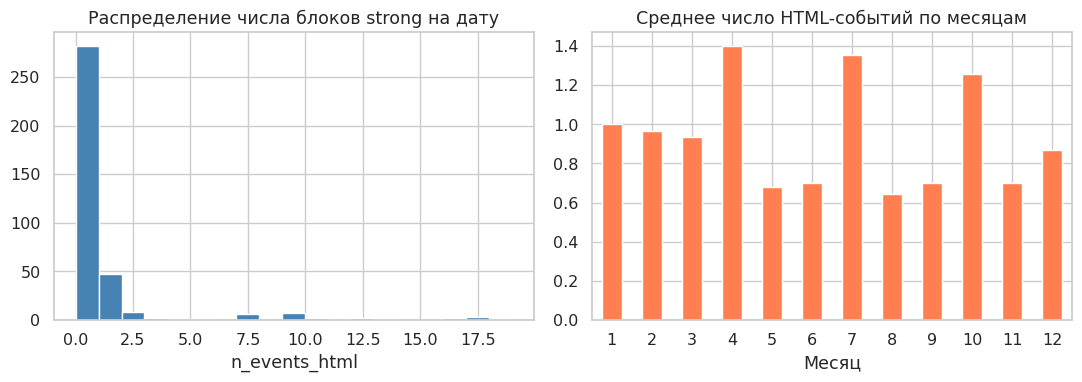

In [6]:
print(f"Строк в df_days: {len(df_days):,}")
print(
    "Даты:",
    df_days["date"].min(),
    "—",
    df_days["date"].max(),
)
print("\nТип дня (day_type):")
print(df_days["day_type"].value_counts(dropna=False))
print("\nСобытия в HTML (<strong>), шт. на дату:")
display(df_days["n_events_html"].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_days["n_events_html"], bins=range(0, df_days["n_events_html"].max() + 2), color="steelblue", edgecolor="white")
axes[0].set_title("Распределение числа блоков strong на дату")
axes[0].set_xlabel("n_events_html")

df_days.groupby("month")["n_events_html"].mean().plot.bar(ax=axes[1], color="coral", rot=0)
axes[1].set_title("Среднее число HTML-событий по месяцам")
axes[1].set_xlabel("Месяц")
plt.tight_layout()
plt.show()

**Интерпретация: сырые дни календаря до отбора налогов (M4)**

Гистограмма **числа HTML-блоков `<strong>`** на дату отражает «насыщенность» страницы календаря: много событий в один день даёт высокий счётчик. Среднее число таких блоков **по месяцам** (вторая панель) показывает **сезонность публикаций** ФНС: отдельные месяцы могут систематически содержать больше записей не только из-за налогов, но и из-за прочих объявлений — поэтому дальнейший отбор «важных» налогов критичен, чтобы не путать шум с экономически значимыми датами.

## 3. EDA

- Сколько дней в году затронут каждый налог
- Распределение числа «важных» налогов на одну дату
- Тепловая карта: месяц × день месяца (есть ли событие по любому из отобранных налогов)

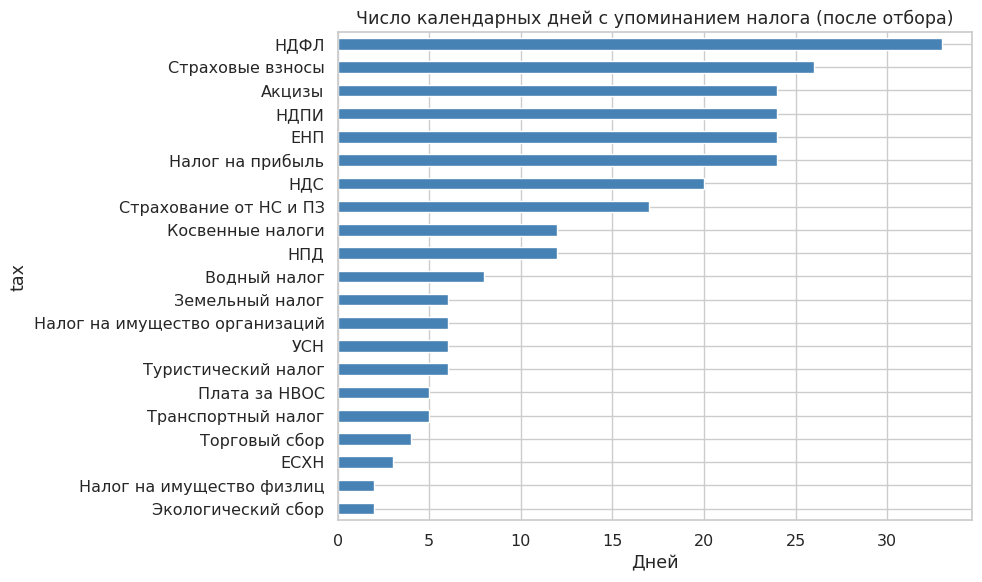

In [7]:
counts = exploded["tax"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
counts.plot.barh(ax=ax, color="steelblue")
ax.set_title("Число календарных дней с упоминанием налога (после отбора)")
ax.set_xlabel("Дней")
plt.tight_layout()
plt.show()

**Интерпретация: частота налогов по календарным дням (M4)**

Горизонтальная столбчатая диаграмма ранжирует налоги по числу дней, в которые они встречаются в выборке после отбора правил. **Длинные полосы** — налоги, которые чаще всего «отмечают» календарь (больше событий в истории); **короткие** — редкие или недавно добавленные категории. Неравномерность распределения ожидаема: несколько крупных платежей обычно дают основную массу дат. Это помогает проверить, не перекошена ли модель в сторону одного-двух налоговых типов.

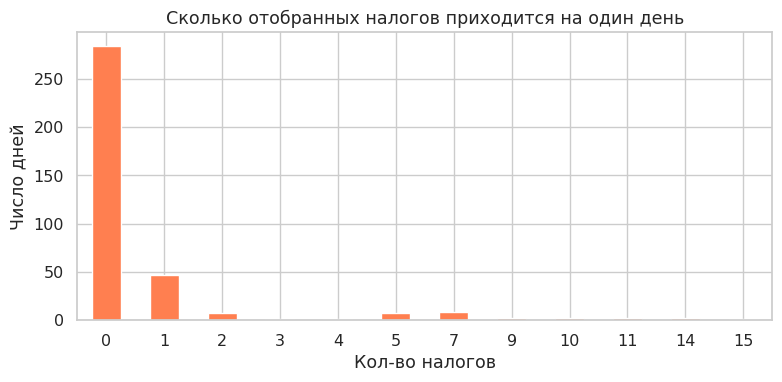

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
df_days["n_important"].value_counts().sort_index().plot.bar(
    ax=ax, color="coral", rot=0
)
ax.set_title("Сколько отобранных налогов приходится на один день")
ax.set_xlabel("Кол-во налогов")
ax.set_ylabel("Число дней")
plt.tight_layout()
plt.show()

**Интерпретация: сколько налогов на одну дату (M4)**

Столбчатая диаграмма по **n_important** показывает, насколько часто в один календарный день попадает **несколько** крупных налогов сразу. Если доминирует столбец «1», большинство напряжённых дней изолированы; высокие столбцы при 2–3 и более означают **кластеризацию** сроков — такие дни могут сильнее влиять на ликвидность и должны учитываться как отдельный режим.

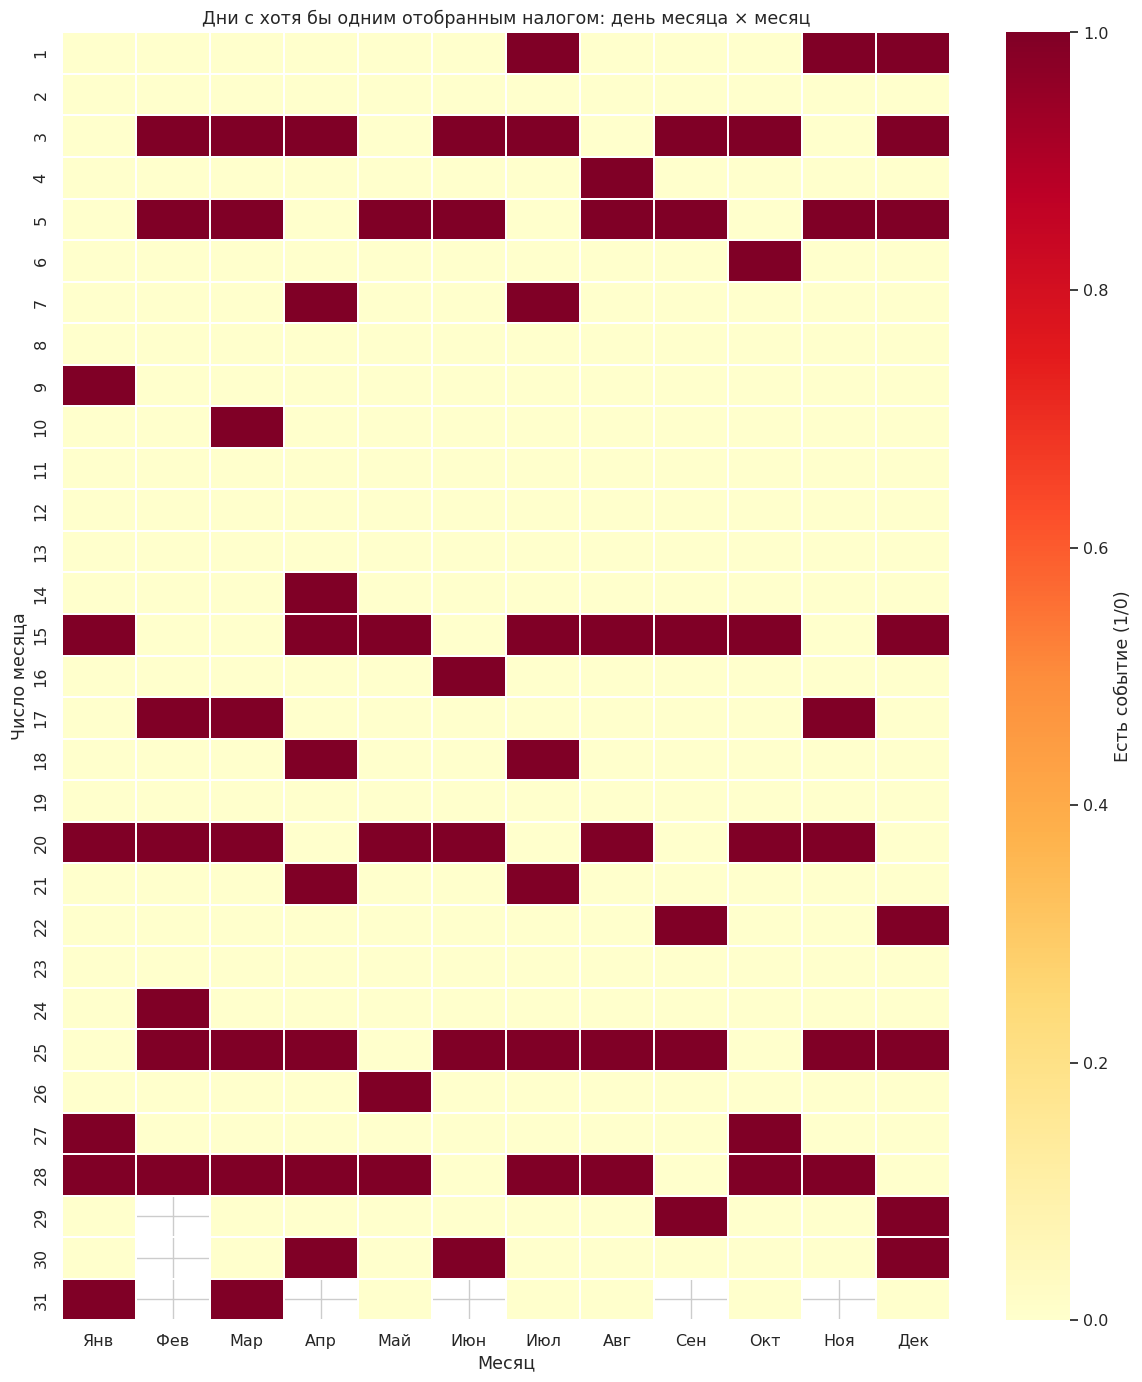

In [ ]:
cal = df_days.copy()
cal["has_any"] = (cal["n_important"] > 0).astype(int)
pivot = cal.pivot_table(
    index="day", columns="month", values="has_any", aggfunc="max"
)
month_labels = ["Янв", "Фев", "Мар", "Апр", "Май", "Июн", "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"]
pivot.columns = [month_labels[i - 1] for i in pivot.columns]

fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    cbar_kws={"label": "Есть событие (1/0)"},
    linewidths=0.3,
    ax=ax,
)
ax.set_title("Дни с хотя бы одним отобранным налогом: день месяца × месяц")
ax.set_xlabel("Месяц")
ax.set_ylabel("Число месяца")
plt.tight_layout()
plt.show()

**Интерпретация: календарная тепловая карта (M4)**

По оси **день месяца** и **месяц** закрашиваются дни, когда в календаре ФНС есть **хотя бы одно** отобранное «важное» налоговое событие. Яркие вертикальные или горизонтальные полосы указывают на **повторяющиеся календарные паттерны** (типичные сроки уплаты в определённые числа месяца). Отдельные яркие клетки — редкие, но регулярные даты. Это полезно для понимания сезонности налоговой нагрузки и для проверки, не дублирует ли календарь слишком узкий набор дней (что важно при построении признаков для моделей).

In [10]:
# Сырые заголовки, которые не попали в отбор (для настройки правил)
from collections import Counter

all_raw = [h for row in df_days["raw_headers"] for h in row]
raw_counter = Counter(all_raw)
print("Всего уникальных сырых заголовков strong:", len(raw_counter))
print("\nПримеры НЕ отобранных заголовков:")
for h, c in raw_counter.most_common():
    if not any(p.search(h) for _, p in IMPORTANT_TAX_RULES):
        print(f"  {c:3d}  {h[:90]}..." if len(h) > 90 else f"  {c:3d}  {h}")

Всего уникальных сырых заголовков strong: 36

Примеры НЕ отобранных заголовков:
   24  Налог на игорный бизнес
   12  Индивидуальный (персонифицированный) учет
   11  Сбор за пользование объектами водных биологических ресурсов
    8  Налог на дополнительный доход
    4  Прослеживаемость товаров
    4  отчет
    1  Упрощенное налоговое декларирование
    1  об операциях с товарами, подлежащими прослеживаемости, совершенных в IV квартале 2024&nbsp...
    1  Бухгалтерская отчетность
    1  об операциях с товарами, подлежащими прослеживаемости, совершенных в I квартале 2025&nbsp;...
    1  Контролируемые сделки
    1  Валютное регулирование и валютный контроль
    1  об операциях с товарами, подлежащими прослеживаемости, совершенных в II квартале 2025&nbsp...
    1  Налоговый мониторинг
    1  об операциях с товарами, подлежащими прослеживаемости, совершенных в III квартале 2025&nbs...


### Экспорт (по желанию)

`feature` — матрица признаков по датам; `exploded` — события в длинном формате для моделей/фильтров.

In [11]:
# feature.to_csv('nalog_calendar_features.csv')
# exploded.to_csv('nalog_calendar_long.csv', index=False)
